# IML Hackathon 2026


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv(
    "../dataset/local_train_set.csv",
    parse_dates=["started_at", "ended_at", "hour_ts"],
    low_memory=False,
)
print(f"Shape: {df.shape}")
print(f"Cities: {sorted(df['city'].unique())}")
df.head()

Shape: (789252, 34)
Cities: ['city 1', 'city 2', 'city 3']


,started_at,ended_at,start_station_id,end_station_id,usage_time_minutes,distance_meters,user_type,start_lat,start_lng,temperature_2m,...,transit_stop_count_500m,distance_to_nearest_rail_station,distance_to_city_center,date,weekday,weekend,holiday,holiday_name,working_day,hour_ts
0,2025-01-01 00:37:00,2025-01-01 01:07:00,1000,300077.0,30.0,NaN,NaN,51.485917,-0.124469,10.5,...,0.0,-1.0,2399.9,2025-01-01,2,0,1,New Year's Day,0,2025-01-01
1,2025-01-01 00:49:00,2025-01-01 02:47:00,1000,1170.0,118.0,NaN,NaN,51.485917,-0.124469,10.5,...,0.0,-1.0,2399.9,2025-01-01,2,0,1,New Year's Day,0,2025-01-01
2,2025-01-01 00:50:00,2025-01-01 02:47:00,1000,1170.0,117.0,NaN,NaN,51.485917,-0.124469,10.5,...,0.0,-1.0,2399.9,2025-01-01,2,0,1,New Year's Day,0,2025-01-01
3,2025-01-01 00:15:00,2025-01-01 00:28:00,1002,3462.0,13.0,NaN,NaN,51.497056,-0.168917,10.3,...,0.0,-1.0,3069.6,2025-01-01,2,0,1,New Year's Day,0,2025-01-01
4,2025-01-01 00:55:00,2025-01-01 01:17:00,1003,22180.0,22.0,NaN,NaN,51.515308,-0.147203,10.5,...,0.0,-1.0,1605.1,2025-01-01,2,0,1,New Year's Day,0,2025-01-01


## 1. Dataset Overview

In [3]:
# Basic stats per city
for city, g in df.groupby("city"):
    print(f"\n{'='*50}")
    print(f"City: {city}")
    print(f"  Rides       : {len(g):,}")
    print(f"  Stations    : {g['start_station_id'].nunique():,}")
    print(f"  Date range  : {g['hour_ts'].min()} → {g['hour_ts'].max()}")
    print(f"  Missing lat/lng: {g['start_lat'].isna().sum():,} / {len(g):,}")


City: city 1
  Rides       : 557,823
  Stations    : 803
  Date range  : 2025-01-01 00:00:00 → 2025-02-01 09:00:00
  Missing lat/lng: 2,595 / 557,823

City: city 2
  Rides       : 230,321
  Stations    : 779
  Date range  : 2025-01-01 00:00:00 → 2025-02-04 13:00:00
  Missing lat/lng: 0 / 230,321

City: city 3
  Rides       : 1,108
  Stations    : 171
  Date range  : 2025-01-08 11:00:00 → 2025-01-09 18:00:00
  Missing lat/lng: 1,108 / 1,108


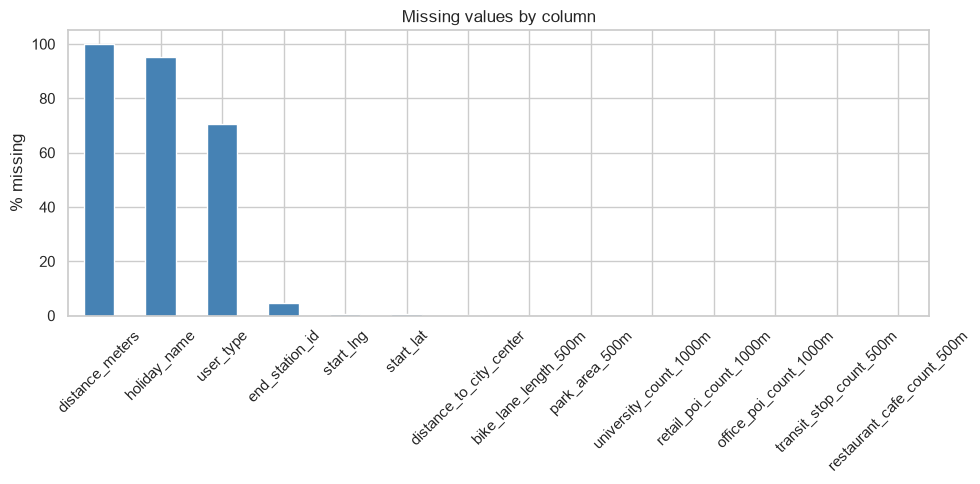

,missing,pct
distance_meters,789252,100.0
holiday_name,752169,95.3
user_type,557823,70.7
end_station_id,35399,4.5
start_lng,3703,0.5
start_lat,3703,0.5
distance_to_city_center,2598,0.3
bike_lane_length_500m,3,0.0
park_area_500m,3,0.0
university_count_1000m,3,0.0


In [4]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
miss_df = miss_df[miss_df["missing"] > 0].sort_values("pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
miss_df["pct"].plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("% missing")
ax.set_title("Missing values by column")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
miss_df

## 2. Target: Hourly Station Demand

Demand distribution per city:
           count  mean   std  min  25%  50%  75%    max
city                                                   
city 1  246822.0  2.26  2.35  1.0  1.0  2.0  3.0  138.0
city 2  115315.0  2.00  1.68  1.0  1.0  1.0  2.0   27.0
city 3     726.0  1.53  1.07  1.0  1.0  1.0  2.0   11.0


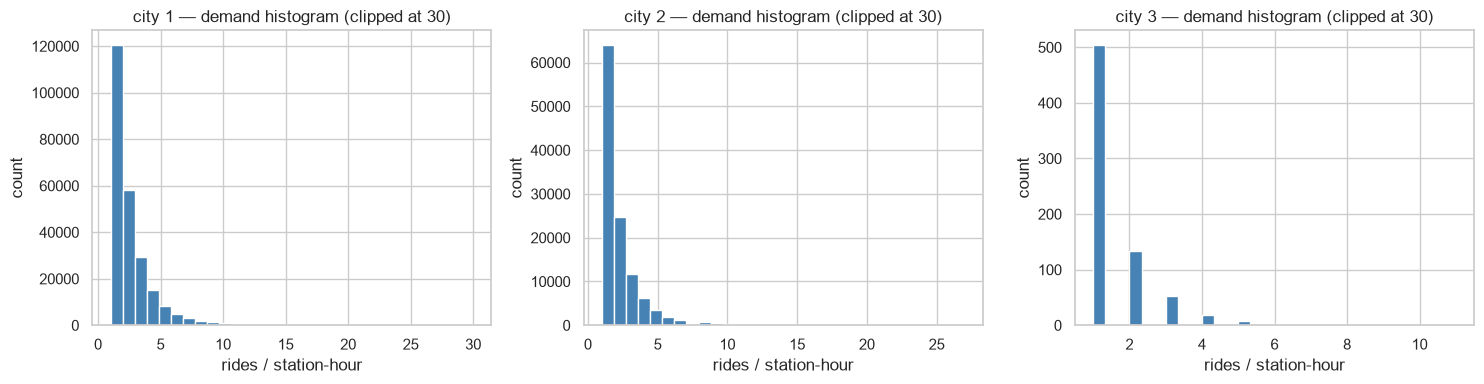

In [5]:
# Aggregate to station-hour demand (our actual prediction target)
demand = (
    df.groupby(["city", "start_station_id", "hour_ts"])
    .size()
    .reset_index(name="demand")
)

print("Demand distribution per city:")
print(demand.groupby("city")["demand"].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (city, g) in zip(axes, demand.groupby("city")):
    ax.hist(g["demand"].clip(upper=30), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{city} — demand histogram (clipped at 30)")
    ax.set_xlabel("rides / station-hour")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 3. Temporal Patterns

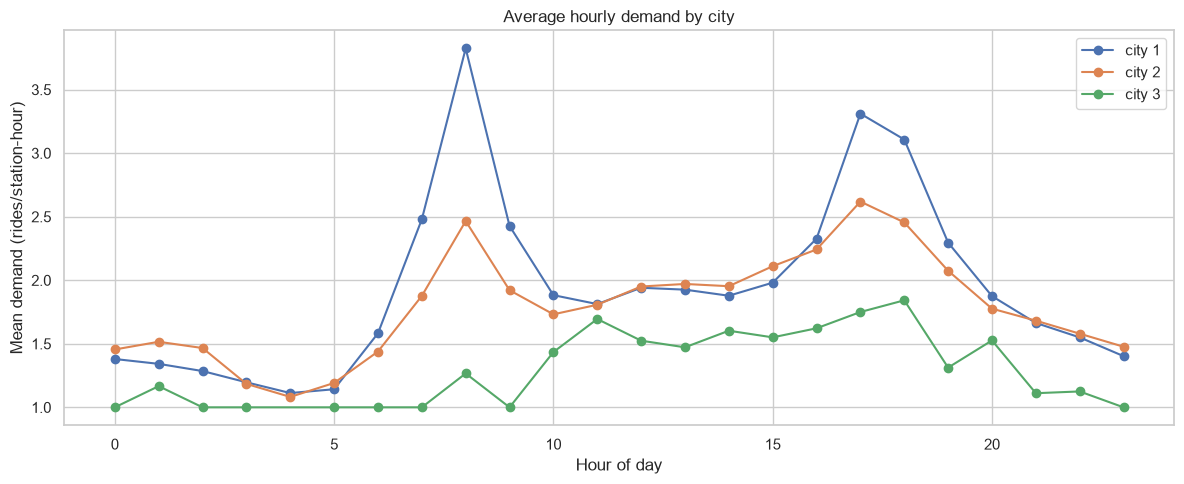

In [6]:
# Average demand by hour-of-day, per city
df["hour"] = df["hour_ts"].dt.hour
df["dayofweek"] = df["hour_ts"].dt.dayofweek  # 0=Mon

hourly = (
    df.groupby(["city", "start_station_id", "hour_ts", "hour"])
    .size()
    .reset_index(name="demand")
    .groupby(["city", "hour"])["demand"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for city, g in hourly.groupby("city"):
    ax.plot(g["hour"], g["demand"], marker="o", label=city)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean demand (rides/station-hour)")
ax.set_title("Average hourly demand by city")
ax.legend()
plt.tight_layout()
plt.show()

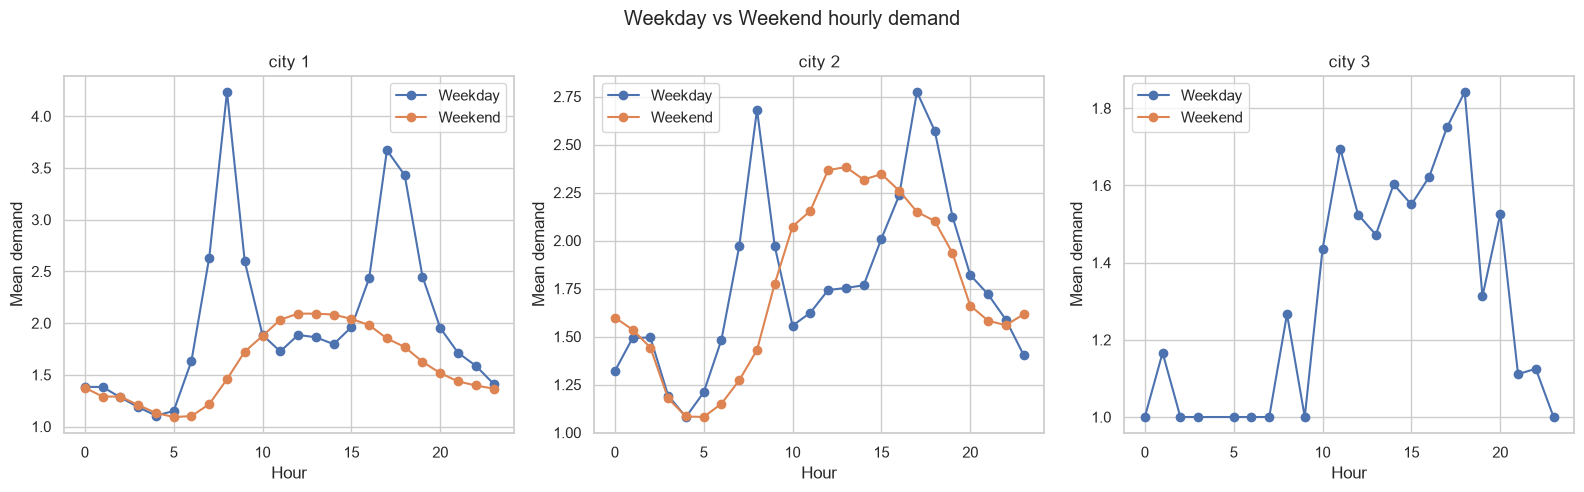

In [7]:
# Weekday vs weekend demand pattern per city
day_hour = (
    df.groupby(["city", "start_station_id", "hour_ts", "hour", "weekend"])
    .size()
    .reset_index(name="demand")
    .groupby(["city", "hour", "weekend"])["demand"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, (city, g) in zip(axes, day_hour.groupby("city")):
    for wk, label in [(0, "Weekday"), (1, "Weekend")]:
        sub = g[g["weekend"] == wk]
        ax.plot(sub["hour"], sub["demand"], marker="o", label=label)
    ax.set_title(city)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Mean demand")
    ax.legend()
plt.suptitle("Weekday vs Weekend hourly demand")
plt.tight_layout()
plt.show()

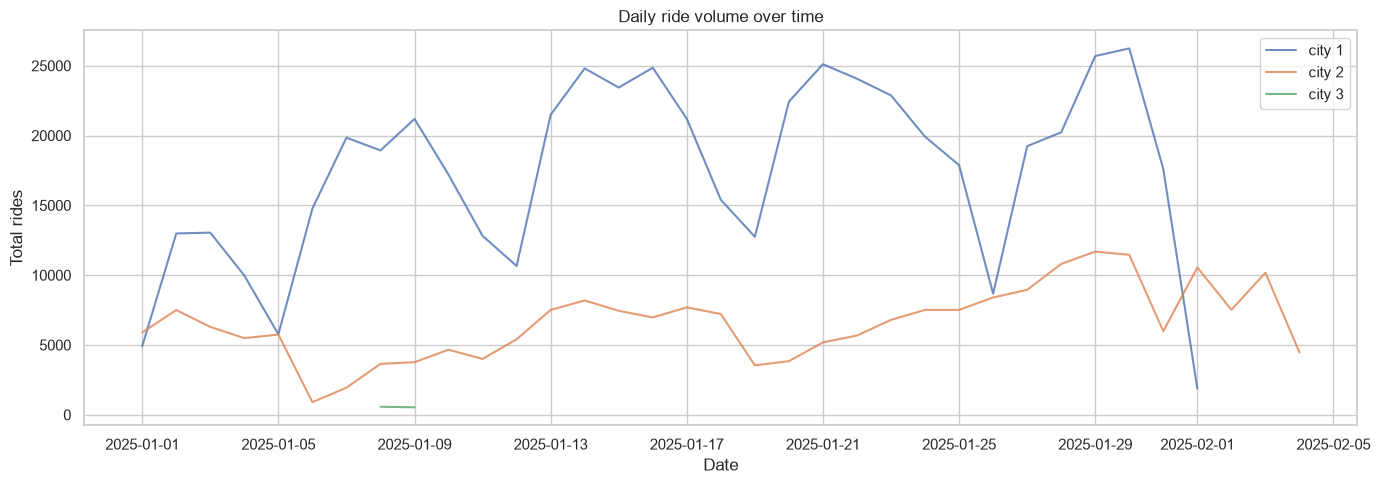

In [8]:
# Daily total rides over time — spot trends and gaps
daily = df.groupby(["city", df["hour_ts"].dt.date]).size().reset_index(name="rides")
daily.columns = ["city", "date", "rides"]
daily["date"] = pd.to_datetime(daily["date"])

fig, ax = plt.subplots(figsize=(14, 5))
for city, g in daily.groupby("city"):
    ax.plot(g["date"], g["rides"], label=city, alpha=0.8)
ax.set_title("Daily ride volume over time")
ax.set_xlabel("Date")
ax.set_ylabel("Total rides")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Station-Level Analysis

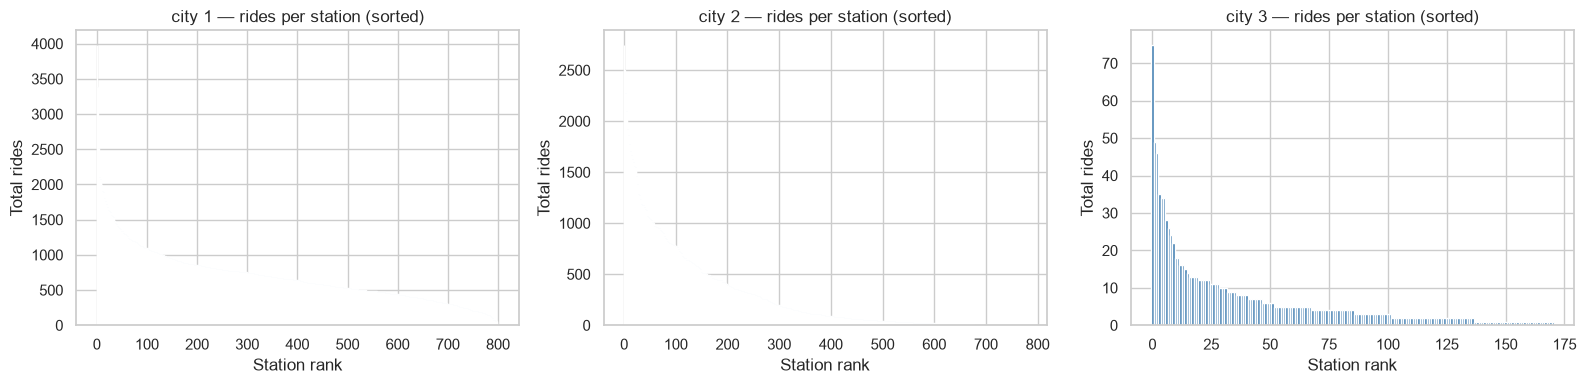


Top 5 busiest stations per city:
  city  start_station_id  rides
city 1              1072   3988
city 1              2696   3380
city 1              2587   2826
city 2             31229   2751
city 1              1011   2521
city 2             31623   2503
city 2             31201   2347
city 2             31101   2273
city 1             22179   2213
city 2             31699   2161
city 3              3005     75
city 3              3035     49
city 3              4215     46
city 3              4613     35
city 3              4214     34


In [10]:
# Station ride volume distribution — are a few stations dominating?
station_rides = df.groupby(["city", "start_station_id"]).size().reset_index(name="rides")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (city, g) in zip(axes, station_rides.groupby("city")):
    g_sorted = g.sort_values("rides", ascending=False).reset_index(drop=True)
    ax.bar(g_sorted.index, g_sorted["rides"], color="steelblue", width=1.0)
    ax.set_title(f"{city} — rides per station (sorted)")
    ax.set_xlabel("Station rank")
    ax.set_ylabel("Total rides")
plt.tight_layout()
plt.show()

print("\nTop 5 busiest stations per city:")
print(station_rides.sort_values("rides", ascending=False).groupby("city").head(5).to_string(index=False))

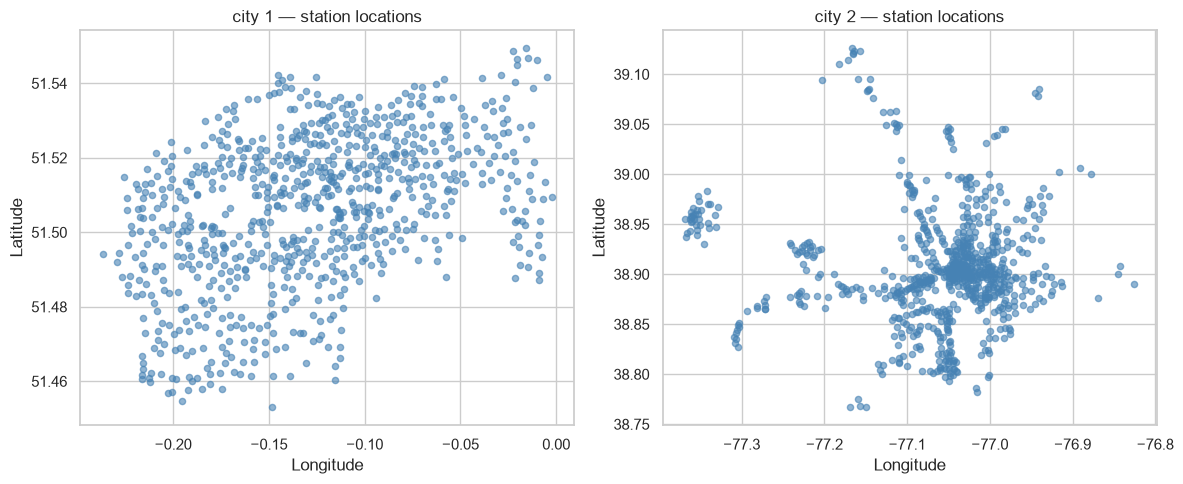

In [11]:
# Station locations (lat/lng scatter) — only cities that have coordinates
has_coords = df.dropna(subset=["start_lat", "start_lng"])
if len(has_coords) > 0:
    station_coords = (
        has_coords.groupby(["city", "start_station_id"])[["start_lat", "start_lng"]]
        .mean()
        .reset_index()
    )
    cities_with_coords = station_coords["city"].unique()
    fig, axes = plt.subplots(1, len(cities_with_coords), figsize=(6 * len(cities_with_coords), 5))
    if len(cities_with_coords) == 1:
        axes = [axes]
    for ax, city in zip(axes, cities_with_coords):
        g = station_coords[station_coords["city"] == city]
        ax.scatter(g["start_lng"], g["start_lat"], s=20, alpha=0.6, color="steelblue")
        ax.set_title(f"{city} — station locations")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("No lat/lng data available.")

## 5. Weather Features

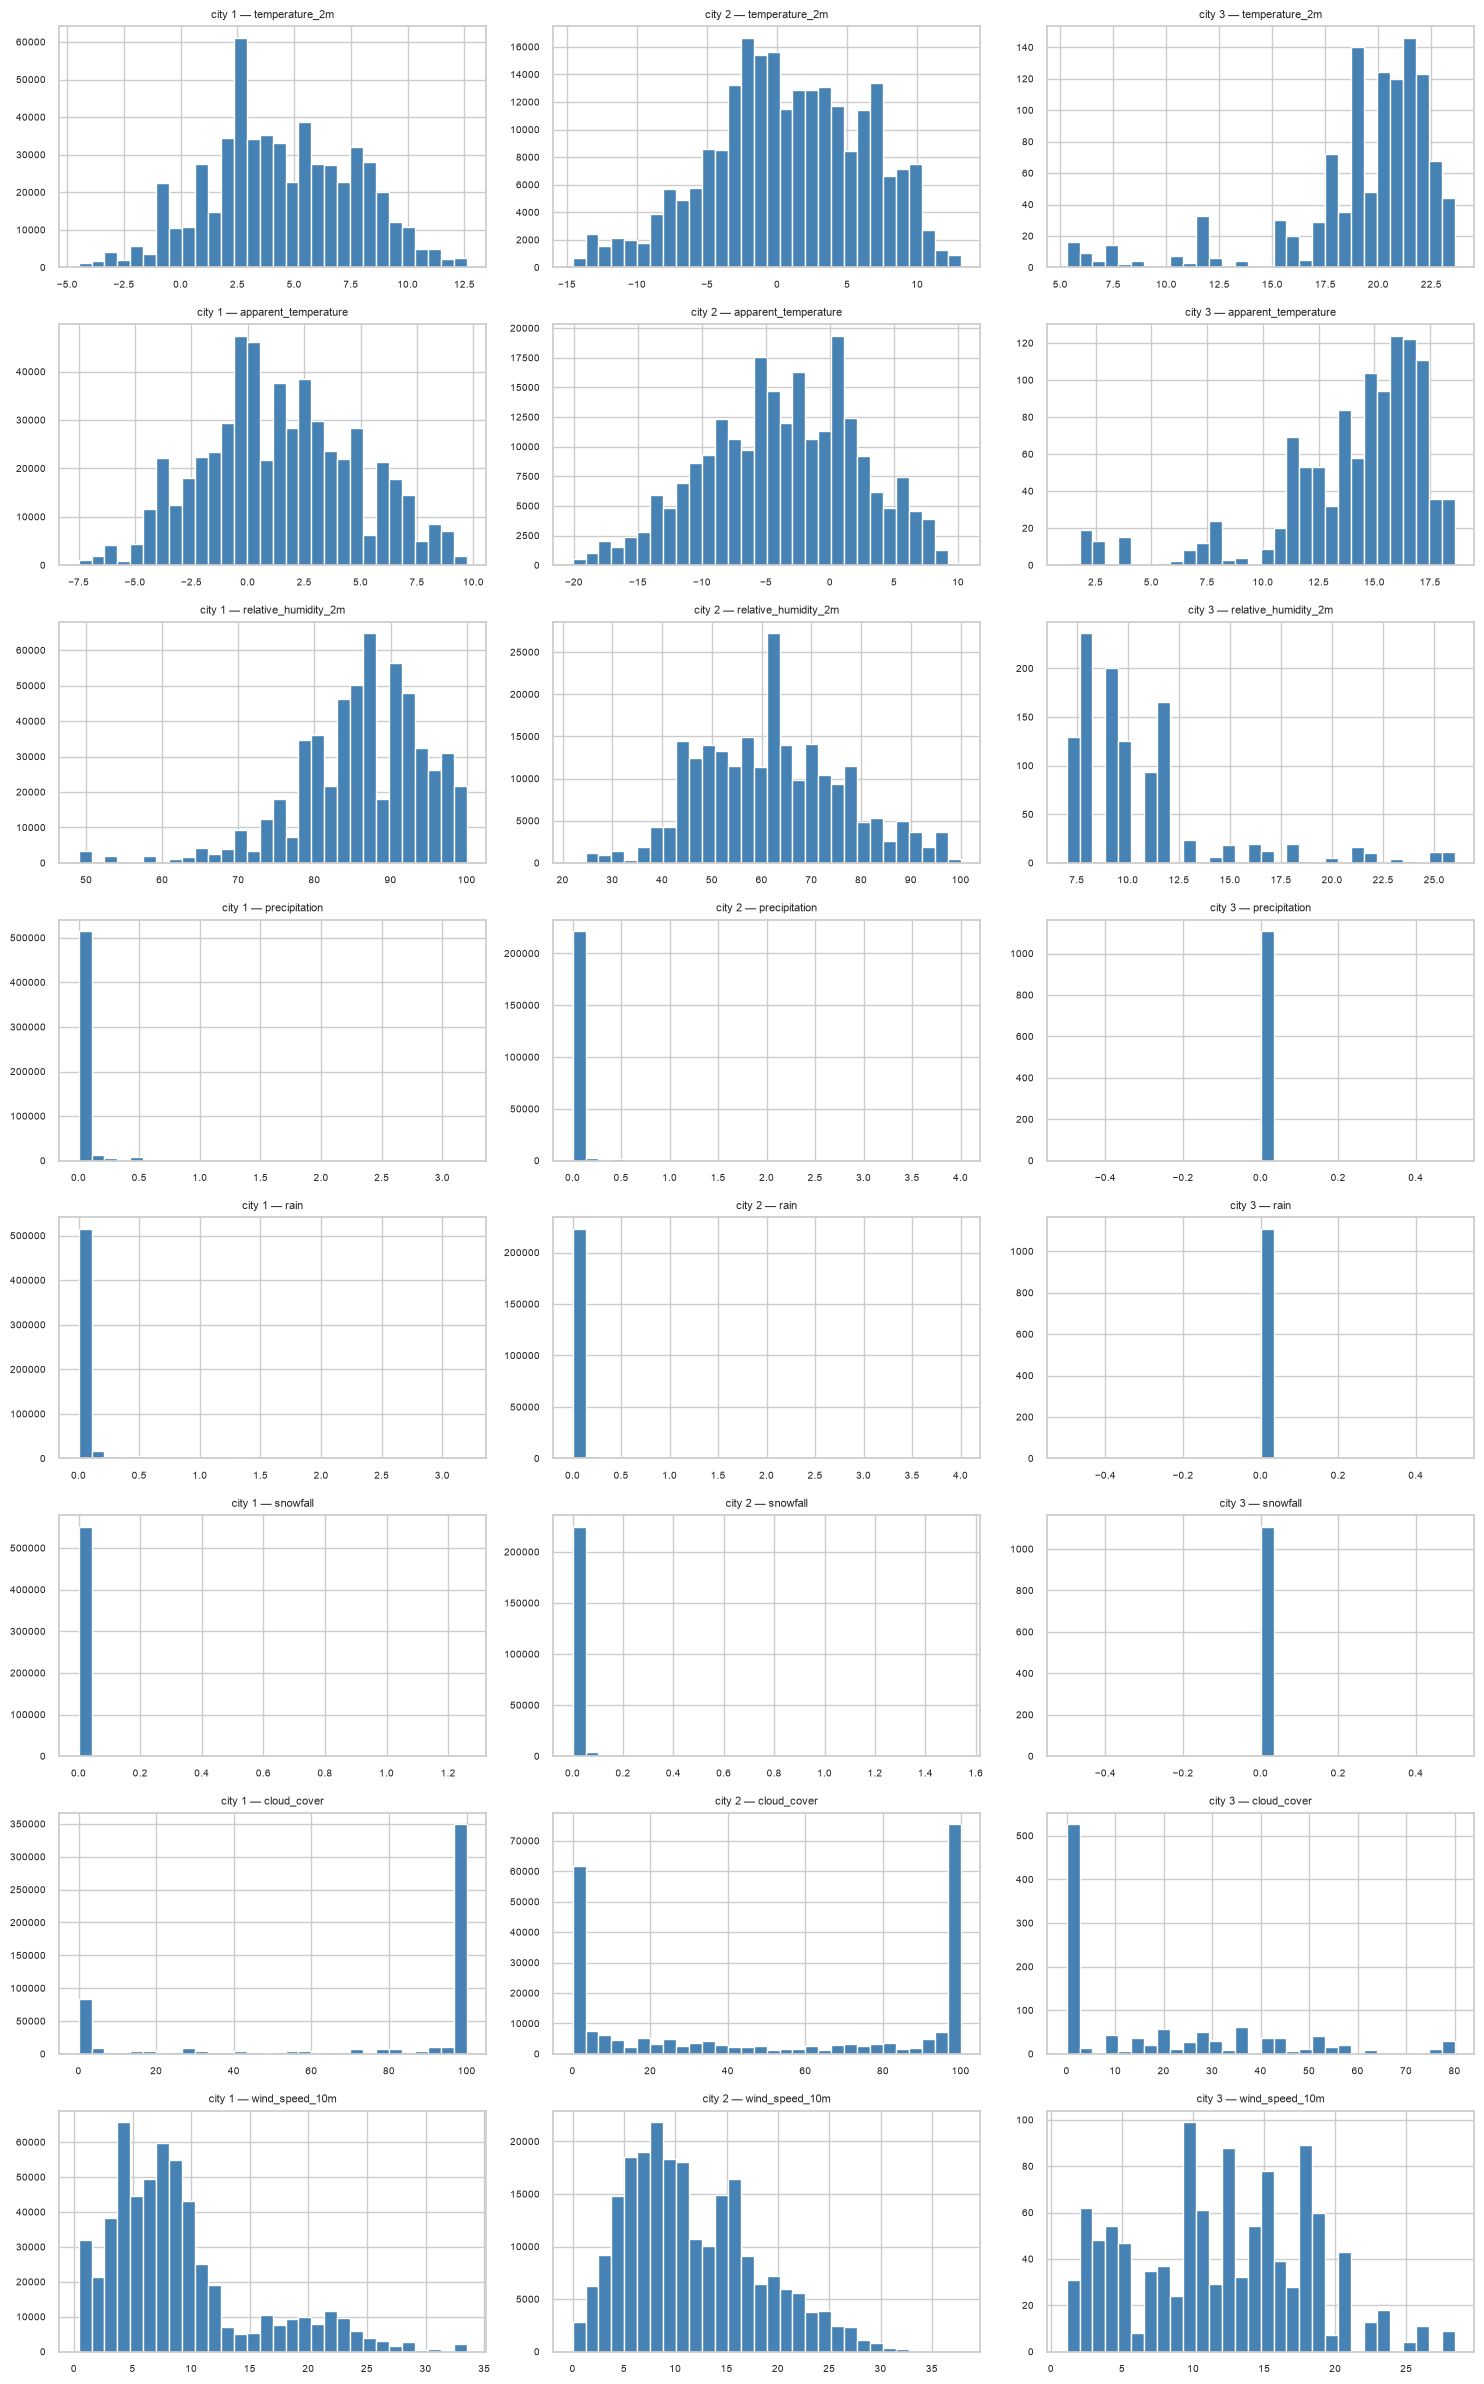

In [12]:
weather_cols = [
    "temperature_2m", "apparent_temperature", "relative_humidity_2m",
    "precipitation", "rain", "snowfall", "cloud_cover", "wind_speed_10m",
]

# Per-city weather distributions
fig, axes = plt.subplots(len(weather_cols), 3, figsize=(15, 3 * len(weather_cols)))
cities = sorted(df["city"].unique())
for row, col in enumerate(weather_cols):
    for col_idx, city in enumerate(cities):
        ax = axes[row, col_idx]
        data = df[df["city"] == city][col].dropna()
        ax.hist(data, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(f"{city} — {col}", fontsize=8)
        ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation between weather and demand
demand_with_weather = (
    df.groupby(["city", "start_station_id", "hour_ts"])
    .agg(demand=("start_station_id", "size"), **{c: (c, "first") for c in weather_cols if c in df.columns})
    .reset_index()
)

print("Correlation of weather features with demand (per city):")
for city, g in demand_with_weather.groupby("city"):
    corr = g[weather_cols + ["demand"]].corr()["demand"].drop("demand").round(3)
    print(f"\n{city}:")
    print(corr.to_string())

## 6. Station Infrastructure & POI Features

In [ ]:
poi_cols = [
    "bike_lane_length_500m", "park_area_500m", "university_count_1000m",
    "office_poi_count_1000m", "retail_poi_count_1000m",
    "restaurant_cafe_count_500m", "transit_stop_count_500m",
    "distance_to_nearest_rail_station", "distance_to_city_center",
]

# One value per station (static metadata)
station_meta = (
    df.groupby(["city", "start_station_id"])[poi_cols]
    .first()
    .reset_index()
)

# Merge with station-level mean demand
station_demand = (
    df.groupby(["city", "start_station_id", "hour_ts"])
    .size()
    .groupby(level=["city", "start_station_id"])
    .mean()
    .reset_index(name="mean_demand")
)
station_meta = station_meta.merge(station_demand, on=["city", "start_station_id"])

# Correlation of POIs with mean station demand
print("Correlation of POI/infrastructure features with mean station demand (per city):")
for city, g in station_meta.groupby("city"):
    available = [c for c in poi_cols if c in g.columns and g[c].notna().sum() > 10]
    corr = g[available + ["mean_demand"]].corr()["mean_demand"].drop("mean_demand").round(3)
    print(f"\n{city}:")
    print(corr.sort_values(ascending=False).to_string())

In [ ]:
# Scatter: distance to city center vs mean demand
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (city, g) in zip(axes, station_meta.groupby("city")):
    if g["distance_to_city_center"].notna().sum() > 5:
        ax.scatter(g["distance_to_city_center"], g["mean_demand"], alpha=0.5, s=20)
        ax.set_xlabel("Distance to city center (m)")
        ax.set_ylabel("Mean rides/station-hour")
        ax.set_title(city)
    else:
        ax.set_title(f"{city} — no data")
plt.suptitle("Distance to city center vs mean demand")
plt.tight_layout()
plt.show()

## 7. Calendar & User Features

In [ ]:
# Mean demand on holidays vs non-holidays
holiday_demand = (
    df.groupby(["city", "start_station_id", "hour_ts", "holiday"])
    .size()
    .reset_index(name="demand")
    .groupby(["city", "holiday"])["demand"]
    .mean()
    .reset_index()
)
holiday_demand["holiday"] = holiday_demand["holiday"].map({0: "Non-holiday", 1: "Holiday"})
print("Mean demand — Holiday vs Non-holiday:")
print(holiday_demand.pivot(index="city", columns="holiday", values="demand").round(3))

# Day-of-week heatmap
dow_hour = (
    df.groupby(["city", "start_station_id", "hour_ts", "dayofweek", "hour"])
    .size()
    .reset_index(name="demand")
    .groupby(["city", "dayofweek", "hour"])["demand"]
    .mean()
    .reset_index()
)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (city, g) in zip(axes, dow_hour.groupby("city")):
    pivot = g.pivot(index="dayofweek", columns="hour", values="demand")
    sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
                yticklabels=day_labels, cbar_kws={"label": "mean demand"})
    ax.set_title(f"{city} — demand heatmap (day × hour)")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Day of week")
plt.tight_layout()
plt.show()

In [ ]:
# User type breakdown per city
if df["user_type"].notna().sum() > 0:
    user_counts = df.groupby(["city", "user_type"]).size().reset_index(name="count")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (city, g) in zip(axes, user_counts.groupby("city")):
        ax.bar(g["user_type"].astype(str), g["count"], color="steelblue")
        ax.set_title(f"{city} — user types")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("user_type column is entirely missing.")

## 8. Station Demand Variance — Which Stations Are Hard to Predict?

In [ ]:
# Coefficient of variation per station: high CV = high relative variance
station_cv = (
    df.groupby(["city", "start_station_id", "hour_ts"])
    .size()
    .reset_index(name="demand")
    .groupby(["city", "start_station_id"])["demand"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
station_cv["cv"] = station_cv["std"] / station_cv["mean"].replace(0, np.nan)

print("Coefficient of variation (std/mean) per city — stations with >= 20 observations:")
for city, g in station_cv[station_cv["count"] >= 20].groupby("city"):
    print(f"\n{city}: median CV={g['cv'].median():.3f}, mean CV={g['cv'].mean():.3f}, max CV={g['cv'].max():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (city, g) in zip(axes, station_cv[station_cv["count"] >= 20].groupby("city")):
    ax.hist(g["cv"].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{city} — CV distribution")
    ax.set_xlabel("Coefficient of variation")
    ax.set_ylabel("# stations")
plt.tight_layout()
plt.show()